In [1]:
!pip install vitaldb
!pip install keras==3.6.0
!pip install tensorflow==2.18.0
!pip install scikit-learn==1.5.1
!pip install scikeras
import keras
import scikeras
import tensorflow
import sklearn

print(f"Keras version: {keras.__version__}")
print(f"SciKeras version: {scikeras.__version__}")
print(f"TensorFlow version: {tensorflow.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

  Using cached tensorflow-2.18.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.3/615.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.2 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.17.1
    Uninstalling tensorflow-2.17.1:
      Successfully uninstalled tensorflow-2.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.18.0 which is incompatible.
  Using cached scikit_learn-1.5.1-cp310

In [2]:
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt
import tensorflow as tf
import vitaldb
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Input, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
SRATE = 128  # Sampling rate in Hz
SEGLEN = 4 * SRATE  # Segment length in samples (512 samples)
MAX_CASES = 100  # Maximum number of cases to process

# Read track and case information from VitalDB
df_trks = pd.read_csv("https://api.vitaldb.net/trks")
df_cases = pd.read_csv("https://api.vitaldb.net/cases")

In [4]:
# Define indices for the data columns
EEG = 0   # EEG data
SEVO = 1  # Sevoflurane concentration
BIS = 2   # Bispectral Index

# Select case IDs that meet inclusion criteria
caseids = set(df_cases.loc[df_cases['age'] > 18, 'caseid']) & \
          set(df_trks.loc[df_trks['tname'] == 'BIS/EEG1_WAV', 'caseid']) & \
          set(df_trks.loc[df_trks['tname'] == 'BIS/BIS', 'caseid']) & \
          set(df_trks.loc[df_trks['tname'] == 'Primus/EXP_SEVO', 'caseid'])

# Initialize lists to store data
x = []  # EEG data
y = []  # Adjusted Sevoflurane concentration (MAC)
b = []  # BIS values
c = []  # Case IDs
icase = 0  # Case counter

# Iterate through each case ID
for caseid in caseids:
    if icase >= MAX_CASES:
        break

    print(f'Loading case {caseid} ({icase + 1}/{MAX_CASES})...', end='', flush=True)

    # Exclude cases with certain anesthetic agents
    try:
        if np.any(vitaldb.load_case(caseid, 'Orchestra/PPF20_CE') > 0.2):
            print('Excluded: Propofol detected')
            continue
    except:
        pass

    try:
        if np.any(vitaldb.load_case(caseid, 'Primus/EXP_DES') > 1):
            print('Excluded: Desflurane detected')
            continue
    except:
        pass

    try:
        if np.any(vitaldb.load_case(caseid, 'Primus/FEN2O') > 2):
            print('Excluded: N2O detected')
            continue
    except:
        pass
    try:
        if np.any(vitaldb.load_case(caseid, 'Orchestra/RFTN50_CE') > 0.2):
            print('Excluded: Remifentanil detected')
            continue
    except:
        pass

    # Load EEG, Sevoflurane concentration, and BIS data
    try:
        vals = vitaldb.load_case(caseid, ['BIS/EEG1_WAV', 'Primus/EXP_SEVO', 'BIS/BIS'], 1 / SRATE)
    except:
        print('Failed to load data')
        continue

    if vals.shape[0] == 0:
        print('No data available')
        continue

 # Exclude cases where maximum SEVO concentration is less than 1
    if np.nanmax(vals[:, SEVO]) < 1:
        print('Excluded: All SEVO <= 1')
        continue

    # Get patient age and adjust Sevoflurane concentration based on age
    age = df_cases.loc[df_cases['caseid'] == caseid, 'age'].values[0]
    vals[:, SEVO] /= 1.80 * 10 ** (-0.00269 * (age - 40))

    # Check for valid BIS values
    if not np.any(vals[:, BIS] > 0):
        print('Excluded: All BIS <= 0')
        continue

    # Trim data to valid BIS indices
    valid_bis_idx = np.where(vals[:, BIS] > 0)[0]
    first_bis_idx = valid_bis_idx[0]
    last_bis_idx = valid_bis_idx[-1]
    vals = vals[first_bis_idx:last_bis_idx + 1, :]

    # Ensure data length is at least 30 minutes
    if len(vals) < 1800 * SRATE:
        print('Excluded: Data length less than 30 min')
        continue

    # Forward fill NaNs in SEVO and BIS columns
    df_vals = pd.DataFrame(vals[:, SEVO:], columns=['SEVO', 'BIS'])
    df_vals = df_vals.ffill(limit=5 * SRATE)
    vals[:, SEVO:] = df_vals.values

    oldlen = len(y)

    # Iterate over data to extract segments
    for irow in range(SEGLEN, len(vals), SRATE):
        bis = vals[irow, BIS]
        mac = vals[irow, SEVO]
        if np.isnan(bis) or np.isnan(mac) or bis == 0:
            continue

        eeg = vals[irow - SEGLEN:irow, EEG]
        if np.isnan(eeg).any():
            continue
        x.append(eeg)
        y.append(mac)
        b.append(bis)
        c.append(caseid)

    icase += 1
    print(f'{len(y) - oldlen} samples read, total {len(y)} samples')


# Convert lists to NumPy arrays
x = np.array(x)
y = np.array(y)
b = np.array(b)
c = np.array(c)

# Exclude invalid samples
print('Excluding invalid samples...', end='', flush=True)
valid_mask = ~np.isnan(x).any(axis=1)
valid_mask &= (np.nanmax(x, axis=1) - np.nanmin(x, axis=1) > 12)
valid_mask &= (np.nanmax(np.abs(x), axis=1) < 100)
x = x[valid_mask]
y = y[valid_mask]
b = b[valid_mask]
c = c[valid_mask]
print(f'{100 * (1 - np.mean(valid_mask)):.1f}% samples removed')

# Get unique case IDs
caseids = np.unique(c)

Loading case 1 (1/100)...Excluded: Desflurane detected
Loading case 2 (1/100)...10376 samples read, total 10376 samples
Loading case 3 (2/100)...Excluded: Propofol detected
Loading case 4 (2/100)...14358 samples read, total 24734 samples
Loading case 5 (3/100)...Excluded: Propofol detected
Loading case 10 (3/100)...14501 samples read, total 39235 samples
Loading case 12 (4/100)...21110 samples read, total 60345 samples
Loading case 18 (5/100)...Excluded: All BIS <= 0
Loading case 19 (5/100)...Excluded: Propofol detected
Loading case 20 (5/100)...Excluded: Propofol detected
Loading case 21 (5/100)...8085 samples read, total 68430 samples
Loading case 24 (6/100)...3599 samples read, total 72029 samples
Loading case 25 (7/100)...9660 samples read, total 81689 samples
Loading case 26 (8/100)...Excluded: Desflurane detected
Loading case 27 (8/100)...11533 samples read, total 93222 samples
Loading case 30 (9/100)...Excluded: Propofol detected
Loading case 33 (9/100)...2794 samples read, tota

In [5]:
# Split data into training and testing sets (80% train, 20% test)
ntest = max(1, int(len(caseids) * 0.2))
caseids_test = caseids[:ntest]
caseids_train = caseids[ntest:]

train_mask = np.isin(c, caseids_train)
test_mask = np.isin(c, caseids_test)

x_train = x[train_mask]
y_train = y[train_mask]
x_test = x[test_mask]
y_test = y[test_mask]

b_train = b[train_mask]
b_test = b[test_mask]


c_test = c[test_mask]

print('====================================================')
print(f'Total: {len(caseids)} cases, {len(y)} samples')
print(f'Train: {len(np.unique(c[train_mask]))} cases, {len(y_train)} samples')
print(f'Test: {len(np.unique(c_test))} cases, {len(y_test)} samples')
print('====================================================')

###New code below: replaced y_train and y_test (mac values) with b_train and b_test (BIS aka DOA predictions)
y_train= b_train
y_test= b_test


# Reshape data for Conv1D input
x_train = x_train.reshape(-1, SEGLEN, 1)
x_test = x_test.reshape(-1, SEGLEN, 1)

Total: 100 cases, 713641 samples
Train: 80 cases, 548428 samples
Test: 20 cases, 165213 samples


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

def create_model(units=64, dropout=0.3):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(SEGLEN, 1)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Bidirectional(LSTM(units, return_sequences=True)))
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(dropout))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mean_absolute_error', optimizer='adam', metrics=['mean_absolute_error'])
    return model

# Define KerasRegressor
model = KerasRegressor(
    model=create_model,  # Use create_model function
    verbose=1
)
param_grid = {
    'model__units': [64, 100],
    'model__dropout': [0.6, 0.7],
    'batch_size': [150, 200, 250],
    'epochs': [10, 15]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=1, cv=2)
grid_result = grid.fit(x_train, y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 114s 61ms/step - loss: 10.6170 - mean_absolute_error: 10.6170
Epoch 2/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 6.5039 - mean_absolute_error: 6.5039
Epoch 3/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 5.4478 - mean_absolute_error: 5.4478
Epoch 4/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.9783 - mean_absolute_error: 4.9783
Epoch 5/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.7651 - mean_absolute_error: 4.7651
Epoch 6/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.6899 - mean_absolute_error: 4.6899
Epoch 7/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.6068 - mean_absolute_error: 4.6068
Epoch 8/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.5256 - mean_absolute_error: 4.5256
Epoch 9/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.5105 - mean_absolute_error: 4.5105
Epoch 10/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.4893 - mean_

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 114s 61ms/step - loss: 10.9999 - mean_absolute_error: 10.9999
Epoch 2/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 6.7077 - mean_absolute_error: 6.7077
Epoch 3/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 5.6090 - mean_absolute_error: 5.6090
Epoch 4/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 5.0269 - mean_absolute_error: 5.0269
Epoch 5/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.8317 - mean_absolute_error: 4.8317
Epoch 6/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.6730 - mean_absolute_error: 4.6730
Epoch 7/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.9511 - mean_absolute_error: 4.9511
Epoch 8/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.5561 - mean_absolute_error: 4.5561
Epoch 9/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.4966 - mean_absolute_error: 4.4966
Epoch 10/10
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 111s 61ms/step - loss: 4.4355 - mean_

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 157s 112ms/step - loss: 12.3323 - mean_absolute_error: 12.3323
Epoch 2/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 8.3227 - mean_absolute_error: 8.3227
Epoch 3/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 6.5037 - mean_absolute_error: 6.5037
Epoch 4/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 5.9094 - mean_absolute_error: 5.9094
Epoch 5/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 5.3249 - mean_absolute_error: 5.3249
Epoch 6/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 5.0195 - mean_absolute_error: 5.0195
Epoch 7/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 4.9077 - mean_absolute_error: 4.9077
Epoch 8/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 4.6692 - mean_absolute_error: 4.6692
Epoch 9/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 4.5717 - mean_absolute_error: 4.5717
Epoch 10/15
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 154s 112ms/step - loss: 4.48

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 93s 82ms/step - loss: 12.6856 - mean_absolute_error: 12.6856
Epoch 2/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 8.0980 - mean_absolute_error: 8.0980
Epoch 3/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 6.7424 - mean_absolute_error: 6.7424
Epoch 4/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 6.0504 - mean_absolute_error: 6.0504
Epoch 5/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 5.6672 - mean_absolute_error: 5.6672
Epoch 6/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 5.3995 - mean_absolute_error: 5.3995
Epoch 7/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 5.2499 - mean_absolute_error: 5.2499
Epoch 8/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 5.0828 - mean_absolute_error: 5.0828
Epoch 9/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 4.9311 - mean_absolute_error: 4.9311
Epoch 10/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 4.8235 - mean_absolute_e

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
 667/1097 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - loss: 14.4838 - mean_absolute_error: 14.4838

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV


def create_model(units=64, dropout=0.3):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(SEGLEN, 1)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Bidirectional(LSTM(units, return_sequences=True)))
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(dropout))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mean_absolute_error', optimizer='adam', metrics=['mean_absolute_error'])
    return model


# Define KerasRegressor
model = KerasRegressor(
    model=create_model,  # Use create_model function
    verbose=1
)
param_grid = {
    'model__units': [64, 100],
    'model__dropout': [0.6, 0.7],
    'batch_size': [150, 200, 250],
    'epochs': [10, 15]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=1, cv=2)
grid_result = grid.fit(x_train, y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 122s 43ms/step - loss: 9.1448 - mean_absolute_error: 9.1448
Epoch 2/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 5.7483 - mean_absolute_error: 5.7483
Epoch 3/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 5.1977 - mean_absolute_error: 5.1977
Epoch 4/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.9855 - mean_absolute_error: 4.9855
Epoch 5/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.8708 - mean_absolute_error: 4.8708
Epoch 6/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 42ms/step - loss: 4.7966 - mean_absolute_error: 4.7966
Epoch 7/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.7449 - mean_absolute_error: 4.7449
Epoch 8/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.6871 - mean_absolute_error: 4.6871
Epoch 9/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 42ms/step - loss: 4.6190 - mean_absolute_error: 4.6190
Epoch 10/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.6027 - mean_ab

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 120s 43ms/step - loss: 9.2495 - mean_absolute_error: 9.2495
Epoch 2/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 5.6965 - mean_absolute_error: 5.6965
Epoch 3/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 5.1430 - mean_absolute_error: 5.1430
Epoch 4/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.9176 - mean_absolute_error: 4.9176
Epoch 5/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.8335 - mean_absolute_error: 4.8335
Epoch 6/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 42ms/step - loss: 4.7369 - mean_absolute_error: 4.7369
Epoch 7/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.6625 - mean_absolute_error: 4.6625
Epoch 8/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.5759 - mean_absolute_error: 4.5759
Epoch 9/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 43ms/step - loss: 4.5223 - mean_absolute_error: 4.5223
Epoch 10/10
2743/2743 ━━━━━━━━━━━━━━━━━━━━ 117s 42ms/step - loss: 4.4541 - mean_ab

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 95s 51ms/step - loss: 10.8595 - mean_absolute_error: 10.8595
Epoch 2/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 51ms/step - loss: 6.0136 - mean_absolute_error: 6.0136
Epoch 3/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 50ms/step - loss: 5.3239 - mean_absolute_error: 5.3239
Epoch 4/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 51ms/step - loss: 5.1432 - mean_absolute_error: 5.1432
Epoch 5/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 51ms/step - loss: 5.0579 - mean_absolute_error: 5.0579
Epoch 6/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 51ms/step - loss: 4.9776 - mean_absolute_error: 4.9776
Epoch 7/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 50ms/step - loss: 4.9216 - mean_absolute_error: 4.9216
Epoch 8/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 50ms/step - loss: 4.8917 - mean_absolute_error: 4.8917
Epoch 9/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 50ms/step - loss: 4.8474 - mean_absolute_error: 4.8474
Epoch 10/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 92s 50ms/step - loss: 4.8167 - mean_absolute_e

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 116s 62ms/step - loss: 10.3406 - mean_absolute_error: 10.3406
Epoch 2/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 5.9124 - mean_absolute_error: 5.9124
Epoch 3/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 5.1225 - mean_absolute_error: 5.1225
Epoch 4/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.9509 - mean_absolute_error: 4.9509
Epoch 5/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.8346 - mean_absolute_error: 4.8346
Epoch 6/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.9683 - mean_absolute_error: 4.9683
Epoch 7/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.7513 - mean_absolute_error: 4.7513
Epoch 8/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.7196 - mean_absolute_error: 4.7196
Epoch 9/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.7023 - mean_absolute_error: 4.7023
Epoch 10/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.7311 - mean_

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 116s 62ms/step - loss: 10.3971 - mean_absolute_error: 10.3971
Epoch 2/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 5.9713 - mean_absolute_error: 5.9713
Epoch 3/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 5.1583 - mean_absolute_error: 5.1583
Epoch 4/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.9778 - mean_absolute_error: 4.9778
Epoch 5/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.8650 - mean_absolute_error: 4.8650
Epoch 6/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.8192 - mean_absolute_error: 4.8192
Epoch 7/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.6844 - mean_absolute_error: 4.6844
Epoch 8/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.6395 - mean_absolute_error: 4.6395
Epoch 9/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 4.5753 - mean_absolute_error: 4.5753
Epoch 10/15
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 113s 62ms/step - loss: 5.0056 - mean_

In [ ]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

def analyze_model(model, x_test, y_test, c_test):
    # Make predictions on the test set
    pred_test = model.predict(x_test).flatten()

    for caseid in np.unique(c_test):
        case_mask = (c_test == caseid)
        pred_test[case_mask] = scipy.signal.medfilt(pred_test[case_mask], kernel_size=15)

    # Calculate Mean Absolute Error
    test_mae = mean_absolute_error(y_test, pred_test)
    print(f'Test MAE: {test_mae}')

    # Calculate correlation coefficient and R-squared
    corr = np.corrcoef(y_test, pred_test)[0, 1]
    r2 = r2_score(y_test, pred_test)
    print(f'Correlation coefficient: {corr}')
    print(f'R squared: {r2}')

    # Scatter plot of actual vs. predicted DOA values
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred_test, s=1, alpha=0.5, color='violet')
    plt.xlabel('Actual DOA')
    plt.ylabel('Predicted DOA')
    plt.title(f'Scatter Plot (Correlation: {corr:.4f})')
    plt.plot([0, 2], [0, 2], 'r--')
    plt.xlim([0, 2])
    plt.ylim([0, 2])
    plt.show()

      # Plot predictions for random test cases
    for caseid in np.random.choice(np.unique(c_test), size=3, replace=False):
        case_mask = (c_test == caseid)
        case_len = np.sum(case_mask)
        if case_len == 0:
            continue
        our_mae = np.mean(np.abs(y_test[case_mask] - pred_test[case_mask]))
        t = np.arange(case_len)
        plt.figure(figsize=(10, 4))
        plt.plot(t, y_test[case_mask], label='Actual DOA')
        plt.plot(t, pred_test[case_mask], label=f'Predicted DOA (DOA: {our_mae:.4f})')
        plt.legend()
        plt.xlabel('Time')
        plt.ylabel('DOA')
        plt.title(f'Case {caseid}')
        plt.show()
        print(f'Case {caseid}, DOA: {our_mae:.4f}')


In [ ]:
#LSTM--- works (tested)

from tensorflow import keras
from tensorflow.keras.layers import Input, RNN, LSTMCell, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Bidirectional, LSTM

model = Sequential()
model.add(LSTM(64,return_sequences=True))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(GlobalAveragePooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64))
model.add(Dense(1))
model.compile(loss='mean_absolute_error', optimizer='adam', metrics=['mean_absolute_error'])

model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=256,
    callbacks=[
        ModelCheckpoint('model.keras', save_best_only=True),
        EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

test_mae, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy}")
print(f"Test MAE: {test_mae}")

Epoch 1/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 139s 62ms/step - loss: 8.9004 - mean_absolute_error: 8.9004 - val_loss: 5.5210 - val_mean_absolute_error: 5.5210
Epoch 2/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 130s 61ms/step - loss: 5.8208 - mean_absolute_error: 5.8208 - val_loss: 5.4419 - val_mean_absolute_error: 5.4419
Epoch 3/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 131s 61ms/step - loss: 4.9443 - mean_absolute_error: 4.9443 - val_loss: 5.1938 - val_mean_absolute_error: 5.1938
Epoch 4/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 131s 61ms/step - loss: 4.7931 - mean_absolute_error: 4.7931 - val_loss: 4.9351 - val_mean_absolute_error: 4.9351
Epoch 5/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 131s 61ms/step - loss: 4.5933 - mean_absolute_error: 4.5933 - val_loss: 4.7890 - val_mean_absolute_error: 4.7890
Epoch 6/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 131s 61ms/step - loss: 4.5229 - mean_absolute_error: 4.5229 - val_loss: 5.1322 - val_mean_absolute_error: 5.1322
Epoch 7/10
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 131s 61ms/step - loss: 4.435

5163/5163 ━━━━━━━━━━━━━━━━━━━━ 92s 18ms/step
Test MAE: 3.6183362532226817
Correlation coefficient: 0.8903530133411133
R squared: 0.7844026511838958


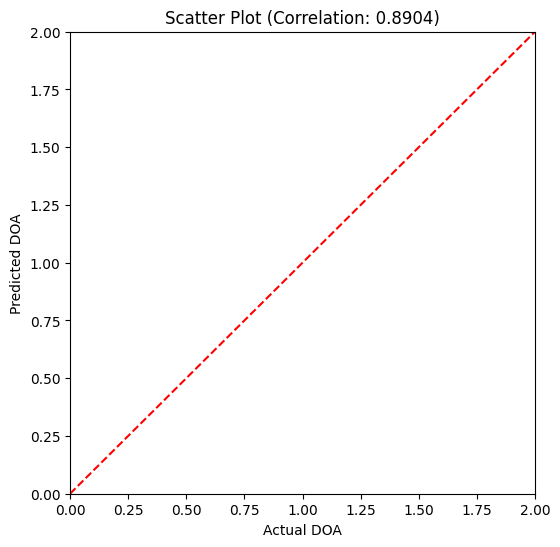

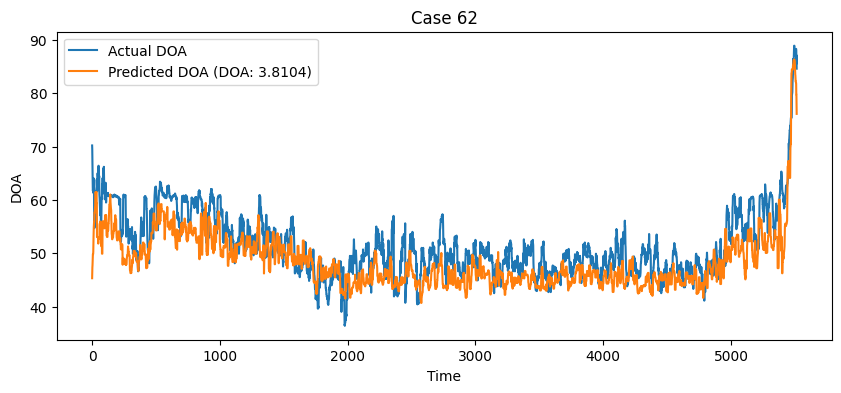

Case 62, DOA: 3.8104


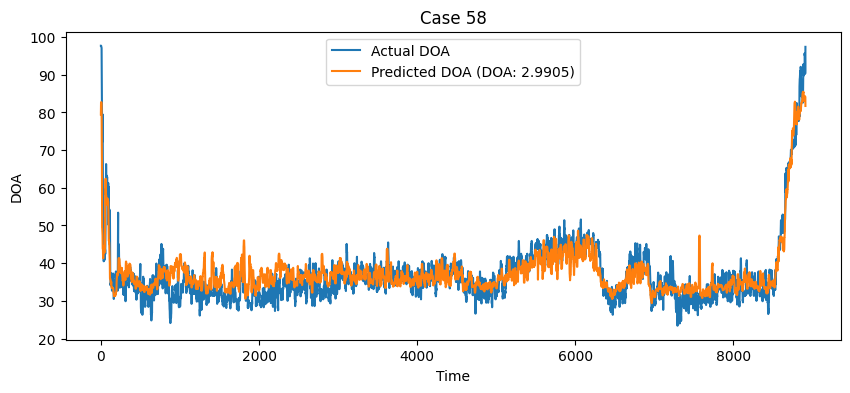

Case 58, DOA: 2.9905


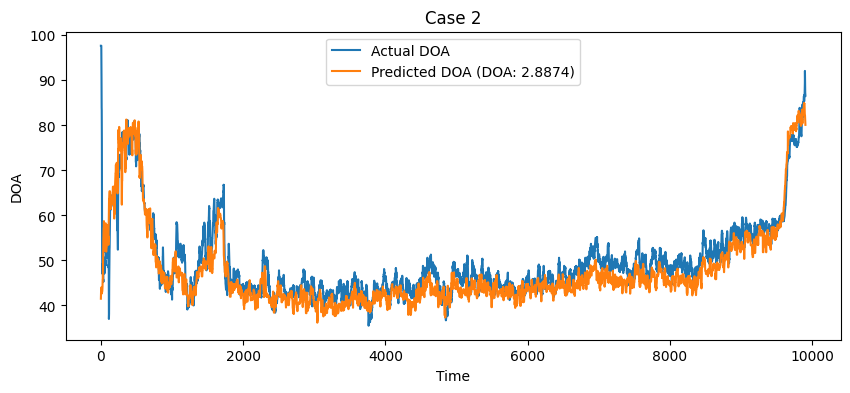

Case 2, DOA: 2.8874


In [ ]:
analyze_model(model, x_test, y_test, c_test)

Epoch 1/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 148s 68ms/step - loss: 10.2549 - mean_absolute_error: 10.2549 - val_loss: 22.3947 - val_mean_absolute_error: 22.3947
Epoch 2/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 144s 67ms/step - loss: 6.2980 - mean_absolute_error: 6.2980 - val_loss: 15.9810 - val_mean_absolute_error: 15.9810
Epoch 3/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 144s 67ms/step - loss: 5.4001 - mean_absolute_error: 5.4001 - val_loss: 10.6738 - val_mean_absolute_error: 10.6738
Epoch 4/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 144s 67ms/step - loss: 4.9338 - mean_absolute_error: 4.9338 - val_loss: 8.8991 - val_mean_absolute_error: 8.8991
Epoch 5/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 144s 67ms/step - loss: 4.9819 - mean_absolute_error: 4.9819 - val_loss: 8.4217 - val_mean_absolute_error: 8.4217
Epoch 6/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 145s 67ms/step - loss: 4.8947 - mean_absolute_error: 4.8947 - val_loss: 7.4652 - val_mean_absolute_error: 7.4652
Epoch 7/15
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 146s 68ms/step - los

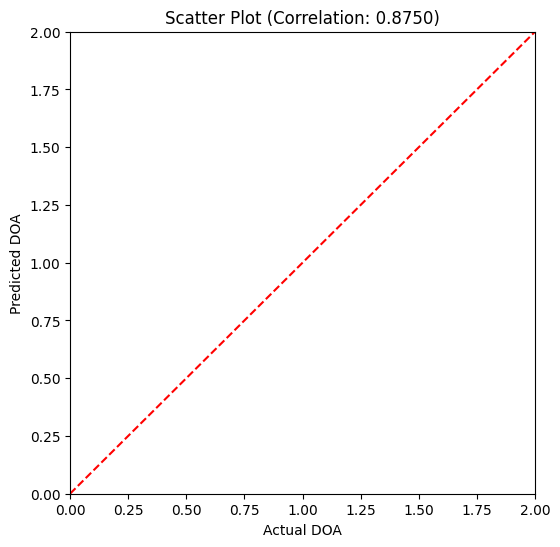

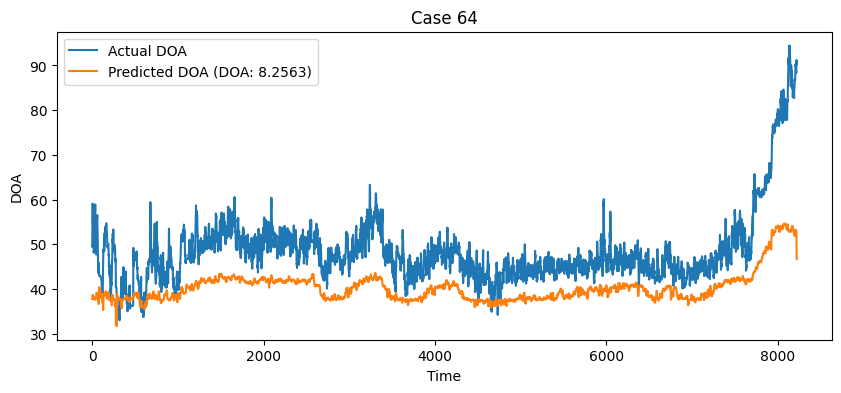

Case 64, DOA: 8.2563


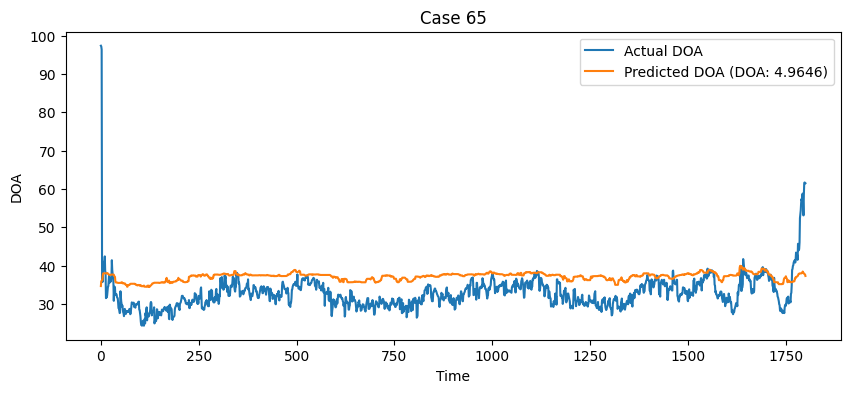

Case 65, DOA: 4.9646


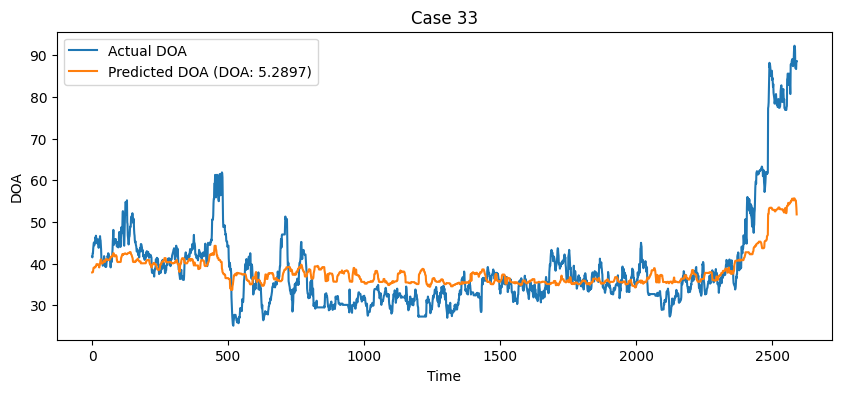

Case 33, DOA: 5.2897


In [ ]:
test_model = Sequential()
test_model.add(LSTM(64,return_sequences=True))
test_model.add(Dense(64, activation='relu'))
test_model.add(Dropout(0.5))
test_model.add(Bidirectional(LSTM(128, return_sequences=True)))
test_model.add(GlobalAveragePooling1D())
test_model.add(Dropout(0.7))
test_model.add(Dense(64, activation='relu'))
test_model.add(Dropout(0.5))
test_model.add(Dense(64, activation='relu'))
test_model.add(Dense(1))
test_model.compile(loss='mean_absolute_error', optimizer='adam', metrics=['mean_absolute_error'])

test_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=15,
    batch_size=256,
    callbacks=[
        ModelCheckpoint('model.keras', save_best_only=True),
        EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

test_mae, test_accuracy = test_model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy}")
print(f"Test MAE: {test_mae}")
print(f"    ")
print(f"    ")
analyze_model(test_model, x_test, y_test, c_test)